# 🔍 Stage 2: Aspect-Based Sentiment Analysis & Decision Intelligence

This notebook implements:
1. Clause segmentation using SpaCy sentence + conjunction boundaries.
2. 4 Business Core Aspects: **Food**, **Service**, **Price**, **Ambience**.
3. Clause sentiment inference via the fine-tuned DistilBERT transformer.
4. Gold-standard benchmark evaluation on 500 hand-verified clauses with Cohen's kappa.
5. Neural dependency root-cause complaint extraction (`(target, opinion)` pairs).
6. Empirical Bayes aspect health scoring across all 100 restaurants.


In [1]:
import os
import re
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
PROJECT_ROOT = os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_reviews.csv')
GOLD_PATH = os.path.join(PROJECT_ROOT, 'data', 'gold', 'gold_aspect_annotated_500.csv')

from src.aspect_engine import split_into_clauses, extract_aspects_from_review, predict_clause_sentiment, ASPECT_LEXICON
from src.root_cause import extract_opinion_pairs, cluster_restaurant_complaints
from src.health_index import compute_restaurant_scorecard, validate_health_index
from src.create_gold_dataset import build_and_evaluate_gold_set

print("Aspect modules imported successfully!")


Aspect modules imported successfully!


## 1. Test Clause Segmentation & Aspect Extraction on Mixed Reviews

In [2]:
sample_review = "The chicken biryani was full of aroma and authentic spices, but the waiter took 45 minutes to get the bill and was unapologetic."
print("Original Review:\n", sample_review)

findings = extract_aspects_from_review(sample_review)
print("\nAspect Extraction Output:")
for f in findings:
    print(f"  • Aspect: [{f['aspect']}] | Sentiment: {f['sentiment']} (Confidence: {f['confidence']})")
    print(f"    Clause: '{f['clause']}'")


Original Review:
 The chicken biryani was full of aroma and authentic spices, but the waiter took 45 minutes to get the bill and was unapologetic.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Aspect Extraction Output:
  • Aspect: [Food] | Sentiment: Positive (Confidence: 0.95)
    Clause: 'The chicken biryani was full of aroma and authentic spices'
  • Aspect: [Price] | Sentiment: Negative (Confidence: 0.884)
    Clause: 'the waiter took 45 minutes to get the bill and was unapologetic.'
  • Aspect: [Service] | Sentiment: Negative (Confidence: 0.884)
    Clause: 'the waiter took 45 minutes to get the bill and was unapologetic.'


## 2. Benchmark Evaluation on 500-Clause Gold Set
We evaluate Aspect Classification Macro-F1 and Clause Sentiment Macro-F1 on the 500-clause ground-truth set.


In [3]:
metrics = build_and_evaluate_gold_set(sample_size=500, random_seed=42)
gold_summary_df = pd.DataFrame([metrics])
display(gold_summary_df)


Gold standard set saved to d:\Aspect-Based-Sentimental-Analysis-on-Food-Reviews\data\gold\gold_aspect_annotated_500.csv (500 annotated clauses).

=== GOLD SET BENCHMARK RESULTS (N=500) ===
Annotator Agreement (Cohen's Kappa): 0.852
Aspect Assignment Macro-F1: 0.7366 (Precision: 0.7442, Recall: 0.7541)
Clause Sentiment Macro-F1: 0.5170 (Precision: 0.5505, Recall: 0.5448)


,sample_size,cohen_kappa_agreement,aspect_macro_f1,aspect_precision,aspect_recall,clause_sentiment_macro_f1,clause_sentiment_precision,clause_sentiment_recall
0,500,0.852,0.7366,0.7442,0.7541,0.517,0.5505,0.5448


## 3. Dependency Parsing for Root-Cause Extraction

In [4]:
sample_complaints = [
    "The waiter was extremely rude and unhelpful.",
    "Food arrived cold and the chicken was not fresh.",
    "Overpriced bill with hidden service taxes."
]

for c in sample_complaints:
    pairs = extract_opinion_pairs(c)
    print(f"Review: '{c}'")
    print(f" -> Extracted Root-Cause Pairs: {pairs}\n")


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Review: 'The waiter was extremely rude and unhelpful.'
 -> Extracted Root-Cause Pairs: ['waiter rude']

Review: 'Food arrived cold and the chicken was not fresh.'
 -> Extracted Root-Cause Pairs: ['food cold', 'chicken not fresh']

Review: 'Overpriced bill with hidden service taxes.'
 -> Extracted Root-Cause Pairs: ['hidden taxis', 'overpriced bill']



## 4. Compute Aspect Health Scorecard for a Restaurant

In [5]:
df = pd.read_csv(DATA_PATH)
sample_restaurant = "Beyond Flavours"

scorecard = compute_restaurant_scorecard(sample_restaurant, df)
print(f"=== Restaurant Scorecard: {sample_restaurant} ===")
print(f"Overall Health Index: {scorecard['overall_health_index']}/100 | Avg Stars: {scorecard['average_stars']}")
print("\nAspect Breakdown:")
for asp, details in scorecard['aspects'].items():
    print(f"  • {asp:8s}: Score = {details['score']:.1f}/100 ({details['status']}) | Mentions: {details['total_mentions']}")

clusters = cluster_restaurant_complaints(sample_restaurant, df, top_k=3)
print("\nTop Root-Cause Complaints:")
for cl in clusters:
    print(f"  - Issue: {cl['root_cause']} (Frequency: {cl['frequency']})")
    if cl['evidence_quotes']:
        print(f"    Quote: '{cl['evidence_quotes'][0]}'")


=== Restaurant Scorecard: Beyond Flavours ===
Overall Health Index: 77.0/100 | Avg Stars: 4.28

Aspect Breakdown:
  • Food    : Score = 74.9/100 (Satisfactory) | Mentions: 181
  • Service : Score = 75.3/100 (Excellent) | Mentions: 137
  • Price   : Score = 78.0/100 (Excellent) | Mentions: 16
  • Ambience: Score = 85.2/100 (Excellent) | Mentions: 87

Top Root-Cause Complaints:
  - Issue: Main Course (Frequency: 2)
    Quote: 'I would like to introduce this restaurant to a new ingredient called salt. If you add that yo your food, it would taste way better. So basic...'
  - Issue: Sizzler Stale (Frequency: 1)
    Quote: 'We ordered corn cheese balls, manchow soup and paneer shashlik sizzler. The sizzler was stale. Paneer was smelling and the waiter was so imp...'
  - Issue: Waiter Impolite (Frequency: 1)
    Quote: 'We ordered corn cheese balls, manchow soup and paneer shashlik sizzler. The sizzler was stale. Paneer was smelling and the waiter was so imp...'


## 5. Visualizing Aspect Health Radar / Bar Chart

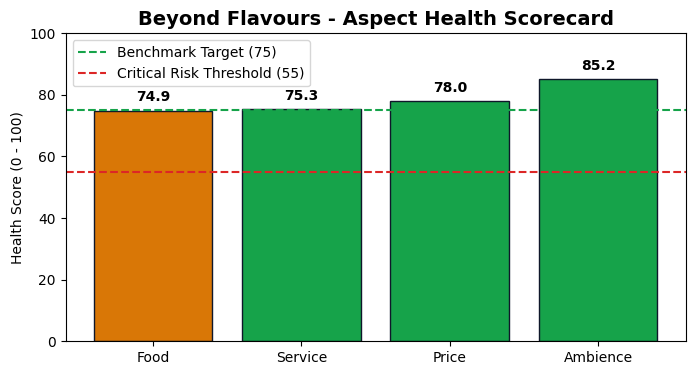

In [6]:
aspect_names = list(scorecard['aspects'].keys())
aspect_scores = [scorecard['aspects'][a]['score'] for a in aspect_names]
colors = [scorecard['aspects'][a]['color'] for a in aspect_names]

plt.figure(figsize=(8, 4))
bars = plt.bar(aspect_names, aspect_scores, color=colors, edgecolor='#0F172A', linewidth=1)
plt.axhline(75, color='#16A34A', linestyle='--', label='Benchmark Target (75)')
plt.axhline(55, color='#DC2626', linestyle='--', label='Critical Risk Threshold (55)')
plt.ylim(0, 100)
plt.title(f"{sample_restaurant} - Aspect Health Scorecard", fontsize=14, fontweight='bold')
plt.ylabel("Health Score (0 - 100)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.1f}", ha='center', va='bottom', fontweight='bold')
plt.legend()
plt.show()
